## **1. Setup and get data**

**1.1 Install Dependencies and Setup**

In [2]:
##!pip install labelme tensorflow opencv-python matplotlib albumentations

In [3]:
##!pip uninstall tensorflow
##!pip install tensorflow==2.15



**1.2 Collect Images Using OpenCV**

In [4]:
import os
import time
import uuid
import cv2

ModuleNotFoundError: No module named 'cv2'

In [ ]:
IMAGES_PATH = os.path.join('data','images')
number_images = 30

cap = cv2.VideoCapture(0)
for imgnum in range(number_images):
    print('Collecting image {}'.format(imgnum))
    ret, frame = cap.read()
    imgname = os.path.join(IMAGES_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame', frame)
    time.sleep(0.5)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

**1.3 Annotate Images with LabelMe**

In [ ]:
!labelme

2025-08-29 01:13:57.020 | INFO     | labelme.config:get_config:66 - Loading config file from: C:\Users\Navan\.labelmerc
2025-08-29 01:13:57.369 | DEBUG    | labelme.widgets.canvas:set_ai_model_name:140 - Setting AI model to 'sam2:latest'


**FROM ABOVE SECTIONS WE COLLECTED THE IMAGES AND ITS DATA FOR TRAINING**


## **NEXT STEP 2**
## **PARTITION AND AUGMENT DATA**

## **2.Review Dataset and Build Image Loading Function**

**2.1 Import TF and Deps**

In [ ]:
import tensorflow as tf
import cv2
import json
import numpy as np
from matplotlib import pyplot as plt

**2.2 limit GPU memory Growth**

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.12.0


In [ ]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus=tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)



In [ ]:
tf.test.is_gpu_available('GPU')

False

**2.3 Load image into TF Data Pipeline**

In [ ]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)

InvalidArgumentError: Expected 'tf.Tensor(False, shape=(), dtype=bool)' to be true. Summarized data: b'No files matched pattern: data\\images\\*.jpg'

In [ ]:
images.as_numpy_iterator().next()

In [ ]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [ ]:
images = images.map(load_image)

NameError: name 'images' is not defined

In [ ]:
images.as_numpy_iterator().next()

NameError: name 'images' is not defined

**2.4 View Raw Images With Matplotlib**

In [ ]:
image_generator = images.batch(4).as_numpy_iterator()

NameError: name 'images' is not defined

In [ ]:
plot_images = image_generator.next()

NameError: name 'image_generator' is not defined

NameError: name 'plot_images' is not defined

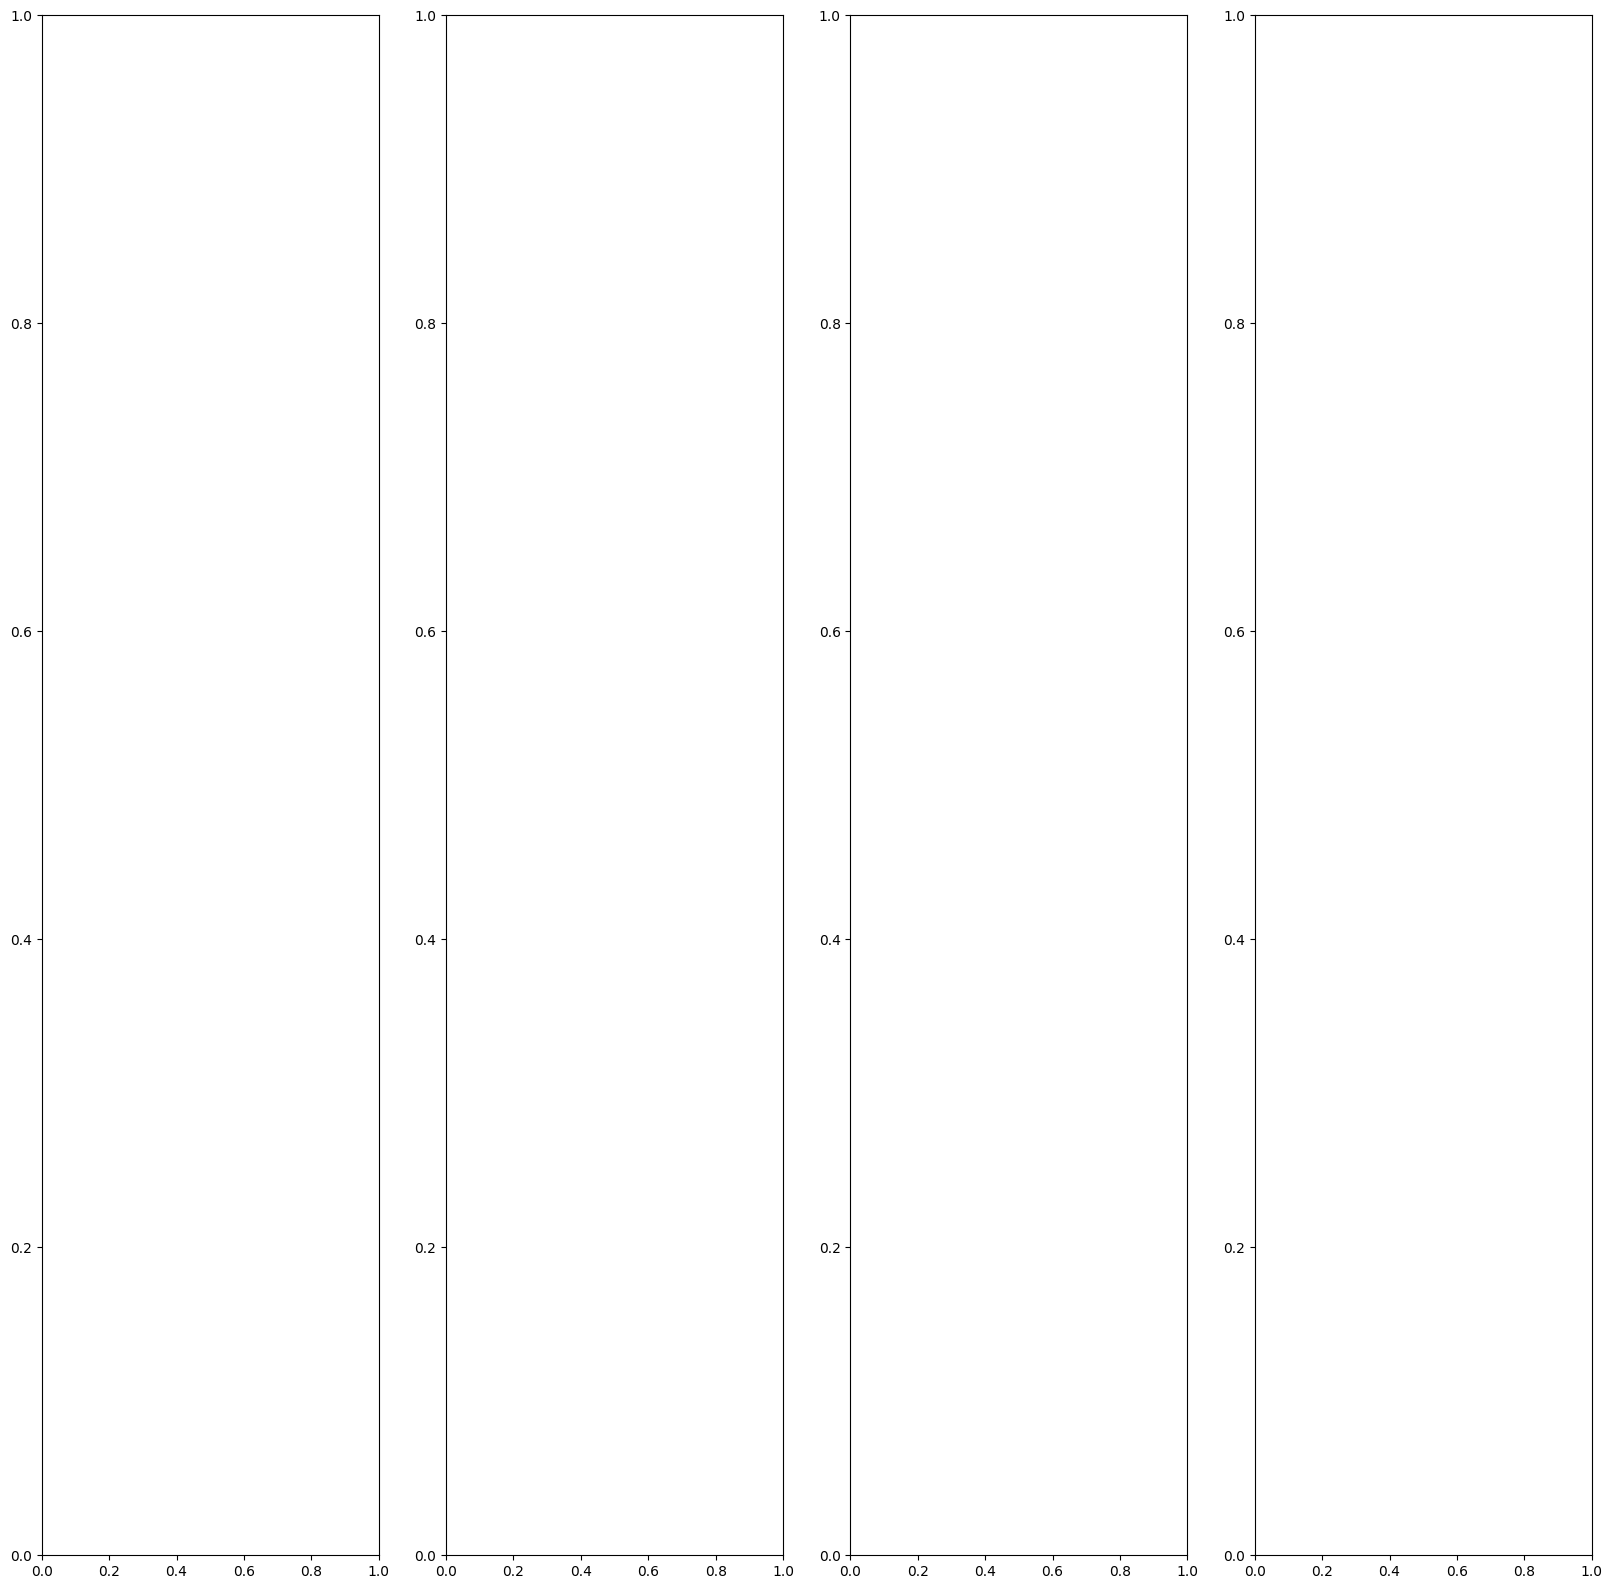

In [ ]:
fig,ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

## **3. Partition Unaugmented Data**

**3.1 Manaually splt data into train test and vald**

In [ ]:
90*.7 #63 photos for training

62.99999999999999

In [ ]:
90*.15 #14 photos for training and 13 for validation

13.5

**3.2 Move the Matching Labels**

In [ ]:
for folder in ['train','test','val']:
    for file in os.listdir(os.path.join('data',folder,'images')):

        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data','labels',filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data',folder,'labels',filename)
            os.replace(existing_filepath, new_filepath)


In [ ]:
img = cv2.imread(os.path.join('data','train','images','008a27ae-7f4a-11f0-ad3f-c475ab582964.jpg'))

In [ ]:
img.shape ##checking the image pixel resolution

(480, 640, 3)

## **4. Apply Image Augmentation on Images and Labels using Albumenatoins**

**4.1 Setup Albumentation Transform Pipeline**

In [ ]:
import albumentations as alb

In [ ]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height=450),
                         alb.HorizontalFlip(p=0.5),
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2),
                         alb.RGBShift(p=0.2),
                         alb.VerticalFlip(p=0.5)],
                        bbox_params=alb.BboxParams(format='albumentations',
                                                  label_fields=['class_labels']))

**4.2 Load a Test Image and Annotation with OpenCV and JSON**

In [ ]:
img = cv2.imread(os.path.join('data','train','images','008a27ae-7f4a-11f0-ad3f-c475ab582964.jpg'))

In [ ]:
img

array([[[215, 216, 212],
        [215, 216, 212],
        [217, 215, 214],
        ...,
        [213, 224, 216],
        [212, 223, 215],
        [210, 223, 215]],

       [[214, 215, 211],
        [214, 215, 211],
        [216, 214, 213],
        ...,
        [214, 222, 215],
        [211, 222, 214],
        [209, 222, 214]],

       [[215, 214, 210],
        [215, 214, 210],
        [217, 213, 212],
        ...,
        [213, 221, 214],
        [212, 220, 213],
        [210, 221, 213]],

       ...,

       [[185, 179, 180],
        [185, 179, 180],
        [185, 180, 181],
        ...,
        [194, 189, 191],
        [196, 189, 192],
        [197, 190, 193]],

       [[185, 180, 179],
        [185, 180, 179],
        [184, 180, 179],
        ...,
        [195, 190, 192],
        [197, 190, 193],
        [198, 191, 194]],

       [[185, 180, 179],
        [184, 179, 178],
        [183, 179, 178],
        ...,
        [195, 190, 192],
        [197, 190, 193],
        [199, 192, 195]]

In [ ]:
with open(os.path.join('data','train','labels','008a27ae-7f4a-11f0-ad3f-c475ab582964.json'),'r') as f:
    label = json.load(f)

In [ ]:
label['shapes'][0]['points']

[[209.2405063291139, 108.98734177215192],
 [487.72151898734177, 464.0506329113924]]

**4.3 Extract Coordinates and Rescale to Match image Resolution**

In [ ]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [ ]:
coords

[209.2405063291139, 108.98734177215192, 487.72151898734177, 464.0506329113924]

In [ ]:
coords = list(np.divide(coords,[640,480,640,480]))

In [ ]:
coords

[0.3269382911392405,
 0.2270569620253165,
 0.7620648734177216,
 0.9667721518987342]

**4.4 Apply Augmentation and view results**

In [ ]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['faces'])

In [ ]:
augmented['bboxes']

[[0.4494233618842231, 0.008776384989420571, 1.0, 0.7978059037526448]]

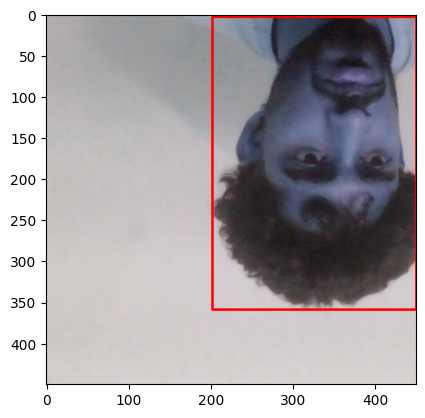

In [ ]:
cv2.rectangle(augmented['image'],
             tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
             tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
                    (255,0,0), 2)
plt.imshow(augmented['image'])

## **5. Build and Run Augmentation Pipeline**

**5.1 Run Augmentation Pipeline**

In [ ]:
for partition in ['train','test','val']: 
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [640,480,640,480]))

        try: 
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0: 
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0 
                    else: 
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else: 
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0 


                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)

x_max is less than or equal to x_min for bbox [3.09137672e-01 4.40664560e-01 5.93354402e-04 9.31170881e-01
 1.00000000e+00].
x_max is less than or equal to x_min for bbox [ 2.68800825e-01  5.02117217e-01 -4.44089216e-17  9.77736533e-01
  1.00000000e+00].
x_max is less than or equal to x_min for bbox [0.75088924 0.34713754 0.41425306 0.8925305  1.        ].
x_max is less than or equal to x_min for bbox [0.89126015 0.32427168 0.50952744 0.93487465 1.        ].
x_max is less than or equal to x_min for bbox [0.83155489 0.32257792 0.45680895 0.91709012 1.        ].
x_max is less than or equal to x_min for bbox [0.85696137 0.3124153  0.48983741 0.92809957 1.        ].
x_max is less than or equal to x_min for bbox [ 2.72611797e-01  4.83485758e-01 -4.44089216e-17  9.75156844e-01
  1.00000000e+00].
x_max is less than or equal to x_min for bbox [0.82140034 0.22310127 0.32220757 0.99791664 1.        ].
x_max is less than or equal to x_min for bbox [0.85315043 0.32765922 0.46379572 0.91370255 1.  

**5.2 Load Augmented Images to TEnsorFlow Dataset**

In [ ]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg' , shuffle = False)
train_images  = train_images.map(load_image)
train_images  = train_images.map(lambda x: tf.image.resize(x,(120,120)))
train_images  = train_images .map(lambda x : x/255)

In [ ]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg' , shuffle = False)
test_images  = test_images.map(load_image)
test_images  = test_images.map(lambda x: tf.image.resize(x,(120,120)))
test_images  = test_images .map(lambda x : x/255)

In [ ]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg' , shuffle = False)
val_images  = val_images.map(load_image)
val_images  = val_images.map(lambda x: tf.image.resize(x,(120,120)))
val_images  = val_images .map(lambda x : x/255)

## **6. Prepare Labels**

**6.1 Build Label Loading Function**

In [ ]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding ="utf-8") as f:
        label = json.load(f)


    return[label['class']], label['bbox']

**6.2 Load Labels to TensorFlow Dataset**

In [ ]:
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json' , shuffle = False)
train_labels = train_labels.map(lambda x : tf.py_function(load_labels,[x],[tf.uint8,tf.float16]))

In [ ]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json' , shuffle = False)
test_labels = test_labels.map(lambda x : tf.py_function(load_labels,[x],[tf.uint8,tf.float16]))

In [ ]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json' , shuffle = False)
val_labels = val_labels.map(lambda x : tf.py_function(load_labels,[x],[tf.uint8,tf.float16]))

In [ ]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.12054, 0.2156 , 0.7393 , 1.     ], dtype=float16))

## **7. Combine Label and Image Samples**

**7.1 Check Partition Lengths**

In [ ]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(3420, 3420, 660, 660, 540, 540)

**7.2 Create Final Datasets(images/labels)**

In [ ]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [ ]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [ ]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [ ]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.506  , 0.2083 , 1.     , 0.9185 ],
        [0.2527 , 0.     , 0.7686 , 0.66   ],
        [0.     , 0.1611 , 0.679  , 1.     ],
        [0.3228 , 0.2211 , 0.967  , 1.     ],
        [0.3113 , 0.2184 , 0.9414 , 1.     ],
        [0.01834, 0.1897 , 0.713  , 1.     ],
        [0.3635 , 0.2393 , 0.847  , 0.809  ],
        [0.0977 , 0.3103 , 0.663  , 1.     ]], dtype=float16))

**7.3 Views Images and Anotation**

In [ ]:
data_samples = train.as_numpy_iterator()

In [ ]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..250.0].


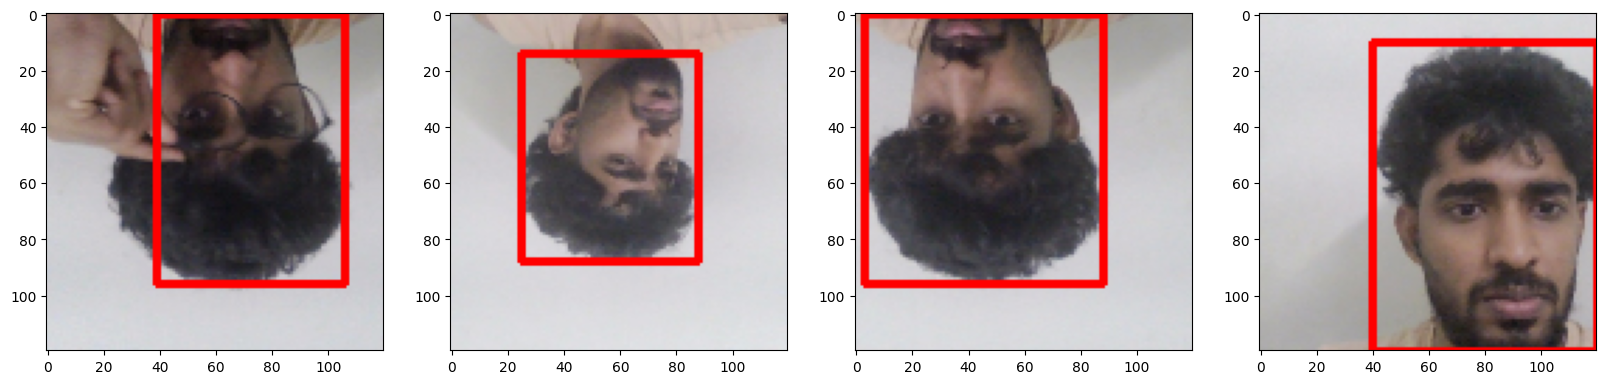

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    # Create a copy of the image to make it writable
    sample_image = res[0][idx].copy()  # Add .copy() to create a writable copy
    sample_coords = res[1][1][idx]

    cv2.rectangle(sample_image,
                 tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                 tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                         (250,0,0), 2)

    ax[idx].imshow(sample_image)

## **BUILD AND TRAIN THE DEEP LEARNING MODEL**

## **8. Build Deep Learning using Functional API**

**8.1 Import Layers and Base Network**

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16

**Download VGG16**

In [ ]:
vgg = VGG16(include_top=False)

In [ ]:
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

**8.3 Build instance of Network**

In [ ]:
def build_model():
    input_layer = Input(shape=(120,120,3))

    vgg = VGG16(include_top=False)(input_layer)

    ##Classification mode
    f1 = GlobalMaxPooling2D()(vgg)
    class1 = Dense(2048, activation='relu')(f1)
    class2 = Dense(1, activation='sigmoid')(class1)
    
    ##Bounding box (Regression) model
    f2 = GlobalMaxPooling2D()(vgg)
    regress1 = Dense(2048, activation='relu')(f2)
    regress2 = Dense(4, activation='sigmoid')(regress1)


    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

**8.4 Test out Neural Network**

In [ ]:
facetracker = build_model()

In [ ]:
facetracker.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 120, 120, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, None, None,   14714688    ['input_2[0][0]']                
                                512)                                                              
                                                                                                  
 global_max_pooling2d (GlobalMa  (None, 512)         0           ['vgg16[0][0]']                  
 xPooling2D)                                                                                  

In [ ]:
X , y = train.as_numpy_iterator().next()

In [ ]:
X.shape

(8, 120, 120, 3)

In [ ]:
classes, coords = facetracker.predict(X)

1/1 [==============================] - 0s 386ms/step


In [ ]:
classes, coords

(array([[0.563221  ],
        [0.45855004],
        [0.5676484 ],
        [0.47373825],
        [0.6198319 ],
        [0.5641341 ],
        [0.47832644],
        [0.5226587 ]], dtype=float32),
 array([[0.34354907, 0.4454396 , 0.5389192 , 0.42380798],
        [0.40400726, 0.3393218 , 0.49237317, 0.36612165],
        [0.36186835, 0.48568377, 0.54005635, 0.35926872],
        [0.41027755, 0.42288026, 0.5634733 , 0.4573806 ],
        [0.38019022, 0.5205614 , 0.46494138, 0.37626654],
        [0.35622042, 0.42635396, 0.5206139 , 0.36116043],
        [0.3758524 , 0.424308  , 0.5678346 , 0.41504487],
        [0.42640683, 0.38664243, 0.56822324, 0.38200635]], dtype=float32))

## **9. Define Losses and Optimizers**

**9.1 Define Optimizers and LR**

In [ ]:
len(train)

428

In [ ]:
batches_per_epoch = len(train)
lr_decay = (1/0.75 -1)/batches_per_epoch

In [ ]:
lr_decay

0.0007788161993769469

In [ ]:
# Option 1: Use the legacy optimizer that still supports 'decay'
opt = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001, decay=lr_decay)

# Option 2: Use the newer optimizer with appropriate parameters
# opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
# Note: If you need decay functionality in newer versions, you might want to use
# learning rate schedulers or the weight_decay parameter depending on your needs

**9.2 Create Localization Loss and Classification Loss**

In [ ]:
def localization_loss(y_true, yhat):
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))

    h_true = y_true[:,3] - y_true[:,1]
    w_true = y_true[:,2] - y_true[:,0]

    h_pred = yhat[:,3] - yhat[:,1]
    w_pred = yhat[:,2] - yhat[:,0]

    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))

    return delta_coord + delta_size

In [ ]:
classloss = tf.keras.losses.BinaryFocalCrossentropy()
regressloss = localization_loss

**9.3 Test out loss Metrics**

In [ ]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=7.1602697>

In [ ]:
classloss(y[0], classes).numpy()

0.14715964

In [ ]:
regressloss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=7.1602697>

## **10. Train Neural Network**

**10.1 Create custom MOdel Class**

In [ ]:
class FaceTracker(Model): 
    def __init__(self, eyetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [ ]:
model = FaceTracker(facetracker)

In [ ]:
model.compile(opt, classloss, regressloss)

**10.2 Train**

In [ ]:
logdir = 'logs'

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=2, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/2
428/428 [==============================] - 392s 908ms/step - total_loss: 0.1292 - class_loss: 0.0036 - regress_loss: 0.1273 - val_total_loss: 0.0115 - val_class_loss: 7.8667e-05 - val_regress_loss: 0.0114
Epoch 2/2
428/428 [==============================] - 389s 870ms/step - total_loss: 0.0331 - class_loss: 8.9107e-04 - regress_loss: 0.0327 - val_total_loss: 0.0084 - val_class_loss: 6.9040e-06 - val_regress_loss: 0.0084


**10.3 Plot Performace**

In [ ]:
hist.history

{'total_loss': [0.011511688120663166, 0.0040579005144536495],
 'class_loss': [9.850415381151834e-07, 5.470952046948696e-08],
 'regress_loss': [0.011511195451021194, 0.004057873040437698],
 'val_total_loss': [0.011470666155219078, 0.008369247429072857],
 'val_class_loss': [7.8667449997738e-05, 6.903974735905649e-06],
 'val_regress_loss': [0.011431332677602768, 0.008365795016288757]}

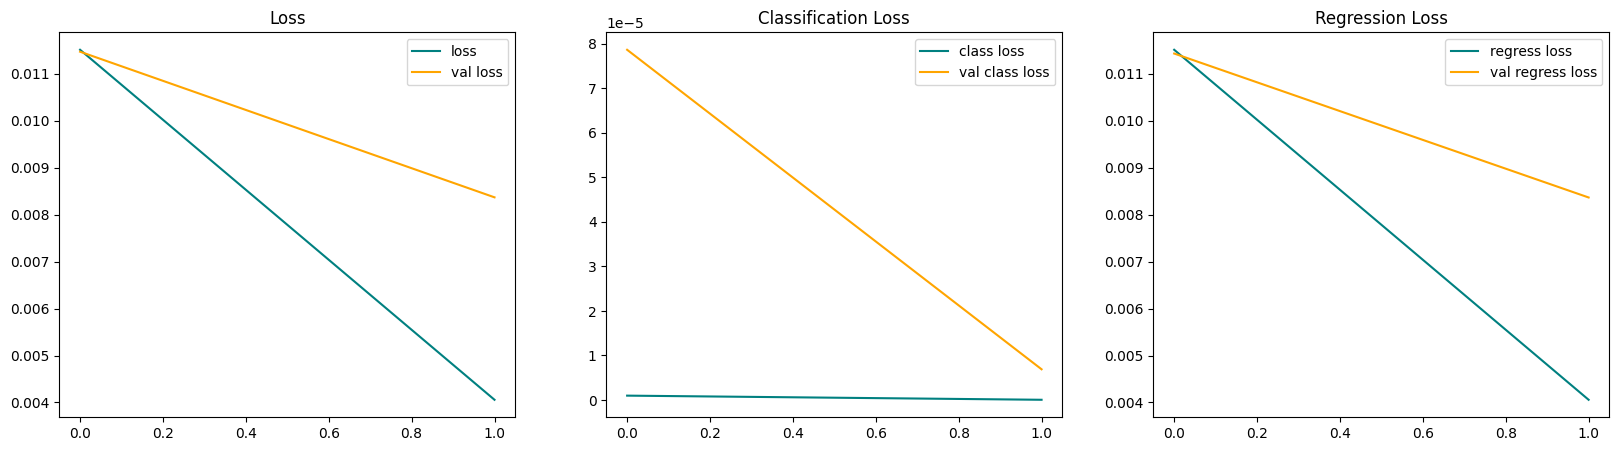

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

## **PART 4**

In [ ]:
test_data = test.as_numpy_iterator()

In [ ]:
test_sample = test_data.next()

In [ ]:
yhat = facetracker.predict(test_sample[0])

1/1 [==============================] - 0s 164ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


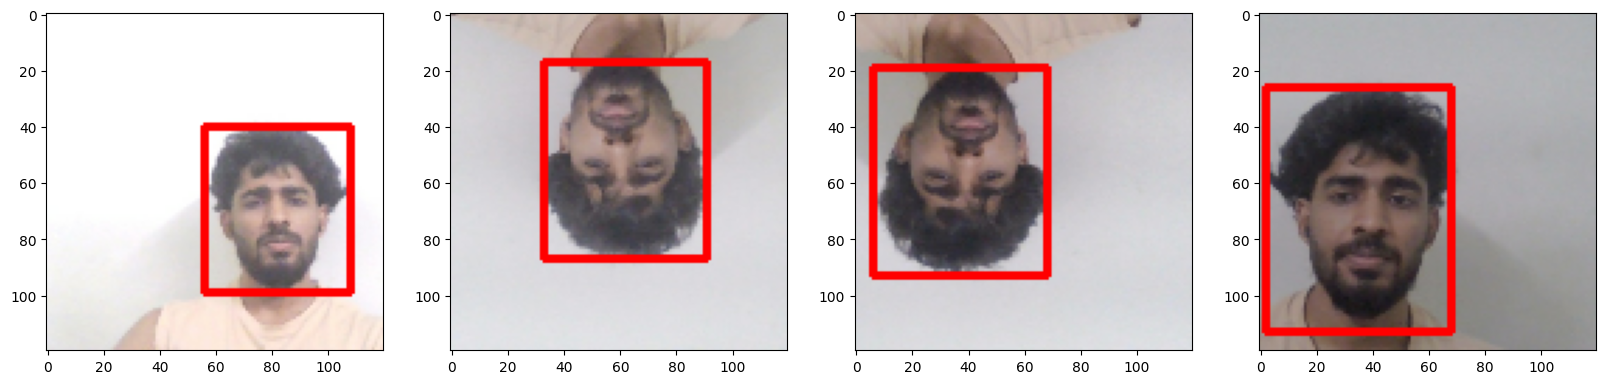

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    # Create a copy of the image to make it writable
    sample_image = test_sample[0][idx].copy()  # Add .copy() to create a writable array
    sample_coords = yhat[1][idx]
    
    if yhat[0][idx] > 0.9:
        cv2.rectangle(sample_image, 
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                            (255,0,0), 2)
    
    ax[idx].imshow(sample_image)

**11.2 Save The Model**

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
facetracker.save('facetracker.h5')

**11.3 Real Time Detection**

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    _ , frame = cap.read()
    frame = frame[50:600, 50:600,:]
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))
    
    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]
    
    if yhat[0] > 0.5: 
        # Controls the main rectangle
        cv2.rectangle(frame, 
                      tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)), 
                            (255,0,0), 2)
        # Controls the label rectangle
        cv2.rectangle(frame, 
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), 
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                    [80,0])), 
                            (255,0,0), -1)
        
        # Controls the text rendered
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    
    cv2.imshow('EyeTrack', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

1/1 [==============================] - 0s 45ms/step
